# Visual comparison: VED-HEV training data vs. `real_obd_001`

Purpose: make the distributional mismatch found during the `real_obd_001`
investigation visually obvious, rather than reading it off percentile
tables. Plots VED-HEV's own training-data feature distributions
side-by-side with `real_obd_001`'s, for the two features that matter
(`rpm_dev`, `engine_load_pct_dev`), restricted to engine-on rows in both
cases (the comparison that actually matters — engine-off/EV-mode rows
were never the issue).

**Run `score_real_vehicle_ved.ipynb` in full first** — its last cell
saves `real_obd_001_scored_w60.parquet` / `..._w30.parquet` to
`dataset/processed/`, and this notebook loads those files directly.
This is a genuinely separate notebook process (different kernel), so it
does not share any in-memory variables with that notebook — loading
from disk is required, not optional.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../dataset/processed")

## Load VED-HEV's own training data + the saved `real_obd_001` scores

In [2]:
ved_train = pd.read_parquet(DATA_DIR / "split" / "ved_hev_train.parquet")
ved_train_w30 = pd.read_parquet(DATA_DIR / "split_w30" / "ved_hev_w30_train.parquet")
ved_raw = pd.read_parquet(DATA_DIR / "ved_hev_clean.parquet", columns=["VehId", "Trip", "time", "rpm"])
ved_train = ved_train.merge(ved_raw, on=["VehId", "Trip", "time"], how="left")
ved_train_w30 = ved_train_w30.merge(ved_raw, on=["VehId", "Trip", "time"], how="left")

real_w60 = pd.read_parquet(DATA_DIR / "real_obd_001_scored_w60.parquet")
real_w30 = pd.read_parquet(DATA_DIR / "real_obd_001_scored_w30.parquet")

ved_engine_on = ved_train[ved_train["rpm"] > 0]
ved_engine_on_w30 = ved_train_w30[ved_train_w30["rpm"] > 0]
real_engine_on = real_w60[real_w60["rpm"] > 0]
real_engine_on_w30 = real_w30[real_w30["rpm"] > 0]

print(f"VED-HEV train (60s): {len(ved_engine_on):,} engine-on rows, {ved_train.VehId.nunique()} vehicles")
print(f"real_obd_001 (60s):  {len(real_engine_on):,} engine-on rows")

VED-HEV train (60s): 2,293,351 engine-on rows, 63 vehicles
real_obd_001 (60s):  757 engine-on rows


## Side-by-side histograms, 60s window

`real_obd_001`'s single session (orange) plotted against VED-HEV's full
training population (blue), same axes, both restricted to engine-on
rows and normalized to density (so the very different sample sizes —
millions of VED rows vs. a few hundred `real_obd_001` rows — don't
distort the shape comparison).

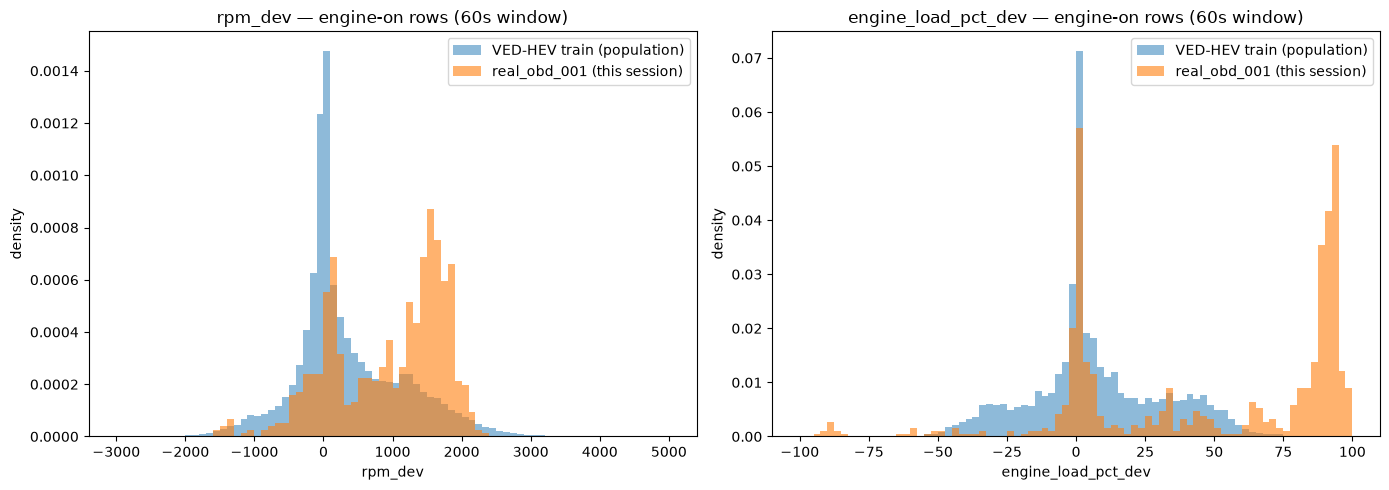

In [3]:
def plot_comparison(ved_df, real_df, title_suffix, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, xlim in [
        (axes[0], "rpm_dev", (-3000, 5000)),
        (axes[1], "engine_load_pct_dev", (-100, 100)),
    ]:
        ax.hist(ved_df[col].dropna(), bins=80, range=xlim, density=True,
                alpha=0.5, label="VED-HEV train (population)", color="tab:blue")
        ax.hist(real_df[col].dropna(), bins=80, range=xlim, density=True,
                alpha=0.6, label="real_obd_001 (this session)", color="tab:orange")
        ax.set_xlabel(col)
        ax.set_ylabel("density")
        ax.set_title(f"{col} — engine-on rows ({title_suffix})")
        ax.legend()
    plt.tight_layout()
    plt.savefig(DATA_DIR / save_name, dpi=120)
    plt.show()

plot_comparison(ved_engine_on, real_engine_on, "60s window", "ved_vs_real_obd_001_comparison_w60.png")

## Same comparison, 30s-window features

If the 30s-window model's improved sealed-test performance is doing
anything to close this gap, it should show up here as the orange
distribution shifting closer to the blue one, compared to the 60s plot
above.

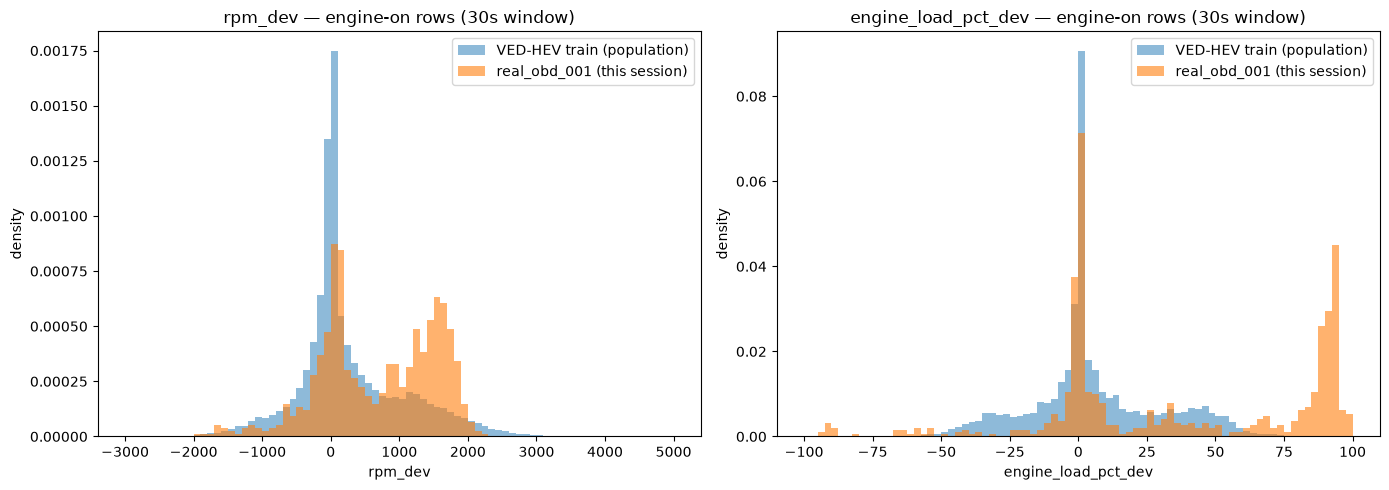

In [4]:
plot_comparison(ved_engine_on_w30, real_engine_on_w30, "30s window", "ved_vs_real_obd_001_comparison_w30.png")